In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import sys
sys.path.append('../series_alignment')
import series_alignment 
from scipy.interpolate import CubicSpline

In [3]:
OPTIM_KWARGS_APDIST = {"optim":"DP", "grid_dim":20, "lambda":0.0}

## Load Experimental Data

In [4]:
path = '../Data/SAXS/Kinetics_Sq/'
filenames = sorted(os.listdir(path))

In [5]:
exp_saxs_data = []
for i in range(0, 10):
    data = np.load(path + filenames[i])
    exp_saxs_data.append(data)
print(f"Loaded {len(exp_saxs_data)} experimental SAXS datasets.")

Loaded 10 experimental SAXS datasets.


## Utilities

In [6]:
from scipy.signal import savgol_filter
from scipy.stats import shapiro
from scipy.signal import find_peaks
from scipy.integrate import trapezoid
import numpy as np

def quantify_saxs_smoothing(x_log, y_log_raw, y_log_smooth):
    residual = y_log_raw - y_log_smooth

    rms_log_residual = np.sqrt(np.mean(residual**2))

    if len(residual) > 1:
        residual_autocorr_lag1 = np.corrcoef(residual[:-1], residual[1:])[0, 1]
    else:
        residual_autocorr_lag1 = np.nan

    try:
        shapiro_stat, shapiro_p = shapiro(residual)
    except Exception:
        shapiro_stat, shapiro_p = np.nan, np.nan

    q = 10**x_log
    I_raw = 10**y_log_raw
    I_smooth = 10**y_log_smooth

    raw_peak_idx = np.argmax(I_raw)
    smooth_peak_idx = np.argmax(I_smooth)
    peak_shift = abs(q[raw_peak_idx] - q[smooth_peak_idx])

    invariant_raw = trapezoid((q**2) * I_raw, q)
    invariant_smooth = trapezoid((q**2) * I_smooth, q)
    invariant_rel_change = abs(invariant_smooth - invariant_raw) / invariant_raw

    return {
        "rms_log_residual": float(rms_log_residual),
        "residual_autocorr_lag1": float(residual_autocorr_lag1),
        "shapiro_p": float(shapiro_p),
        "peak_shift": float(peak_shift),
        "invariant_rel_change": float(invariant_rel_change),
    }

def process_saxs_data(
    x,
    y,
    x_lim=(0.004, 0.03),
    y_lim=(7e-2, 5e0),
    smooth=True,
    sg_window=7,
    sg_poly=2,
    return_metrics=False
):
    mask = (
        (x >= x_lim[0]) & (x <= x_lim[1]) &
        (y >= y_lim[0]) & (y <= y_lim[1])
    )

    x_processed = np.log10(x[mask])
    y_processed = np.log10(y[mask])

    x_unique, unique_indices = np.unique(x_processed, return_index=True)
    y_unique = y_processed[unique_indices]

    if smooth and len(y_unique) >= sg_window:
        if sg_window % 2 == 0:
            sg_window += 1
        sg_window = min(sg_window, len(y_unique) if len(y_unique) % 2 == 1 else len(y_unique) - 1)
        if sg_window >= sg_poly + 2:
            y_unique = savgol_filter(y_unique, sg_window, sg_poly, mode="interp")

    if return_metrics:
        metrics = quantify_saxs_smoothing(x_unique, y_processed[unique_indices], y_unique)
        return x_unique, y_unique, metrics
    return x_unique, y_unique

In [7]:
from IPython.display import display, HTML

def report_saxs_smoothing_metrics(metrics):
    rms_log = metrics.get("rms_log_residual", np.nan)
    typical_linear_change_pct = (10**rms_log - 1) * 100 if np.isfinite(rms_log) else np.nan

    thresholds = {
        "typical_linear_change_pct": (8.0, 20.0),
        "residual_autocorr_lag1": (0.15, 0.35),
        "shapiro_p": (0.05, 0.01),
        "peak_shift": (5e-4, 2e-3),
        "invariant_rel_change": (0.02, 0.08),
    }

    labels = {
        "typical_linear_change_pct": "Typical linear intensity change",
        "residual_autocorr_lag1": "Residual autocorr (lag 1)",
        "shapiro_p": "Shapiro p-value",
        "peak_shift": "Peak shift",
        "invariant_rel_change": "Invariant relative change",
    }

    notes = {
        "typical_linear_change_pct": "Typical percent change introduced by smoothing in linear intensity units.",
        "residual_autocorr_lag1": "Closer to 0 means removed signal looks more like noise.",
        "shapiro_p": "Higher is more consistent with normal residuals; secondary diagnostic only.",
        "peak_shift": "Smaller means smoothing preserved SAXS feature positions.",
        "invariant_rel_change": "Smaller means smoothing preserved integrated SAXS intensity.",
    }

    values = {
        "typical_linear_change_pct": typical_linear_change_pct,
        "residual_autocorr_lag1": metrics.get("residual_autocorr_lag1", np.nan),
        "shapiro_p": metrics.get("shapiro_p", np.nan),
        "peak_shift": metrics.get("peak_shift", np.nan),
        "invariant_rel_change": metrics.get("invariant_rel_change", np.nan),
    }

    def classify(name, value):
        good, moderate = thresholds[name]

        if name == "shapiro_p":
            if value >= good:
                return "Good", "#d4edda", "#155724"
            if value >= moderate:
                return "Moderate", "#fff3cd", "#856404"
            return "Bad", "#f8d7da", "#721c24"

        value = abs(value)
        if value <= good:
            return "Good", "#d4edda", "#155724"
        if value <= moderate:
            return "Moderate", "#fff3cd", "#856404"
        return "Bad", "#f8d7da", "#721c24"

    def fmt(name, value):
        if name == "typical_linear_change_pct":
            return f"{value:.1f}%"
        if name == "shapiro_p":
            return f"{value:.3g}"
        if name == "residual_autocorr_lag1":
            return f"{value:.3f}"
        if name == "invariant_rel_change":
            return f"{value:.2%}"
        return f"{value:.4e}"

    rows = []
    for name in [
        "typical_linear_change_pct",
        "residual_autocorr_lag1",
        "shapiro_p",
        "peak_shift",
        "invariant_rel_change",
    ]:
        value = values[name]
        status, bg, fg = classify(name, value)
        rows.append(
            f"""
            <tr>
                <td style="padding:8px 12px; border:1px solid #ddd;">{labels[name]}</td>
                <td style="padding:8px 12px; border:1px solid #ddd; font-family:monospace;">{fmt(name, value)}</td>
                <td style="padding:8px 12px; border:1px solid #ddd; background:{bg}; color:{fg}; font-weight:600;">{status}</td>
                <td style="padding:8px 12px; border:1px solid #ddd;">{notes[name]}</td>
            </tr>
            """
        )

    html = f"""
    <div style="font-family:Arial, sans-serif; max-width:900px;">
        <h3 style="margin-bottom:10px;">SAXS Smoothing Report</h3>
        <table style="border-collapse:collapse; width:100%;">
            <thead>
                <tr style="background:#f2f2f2;">
                    <th style="padding:8px 12px; border:1px solid #ddd; text-align:left;">Metric</th>
                    <th style="padding:8px 12px; border:1px solid #ddd; text-align:left;">Value</th>
                    <th style="padding:8px 12px; border:1px solid #ddd; text-align:left;">Assessment</th>
                    <th style="padding:8px 12px; border:1px solid #ddd; text-align:left;">Interpretation</th>
                </tr>
            </thead>
            <tbody>
                {''.join(rows)}
            </tbody>
        </table>
    </div>
    """
    display(HTML(html))

## Plot Experimental Data

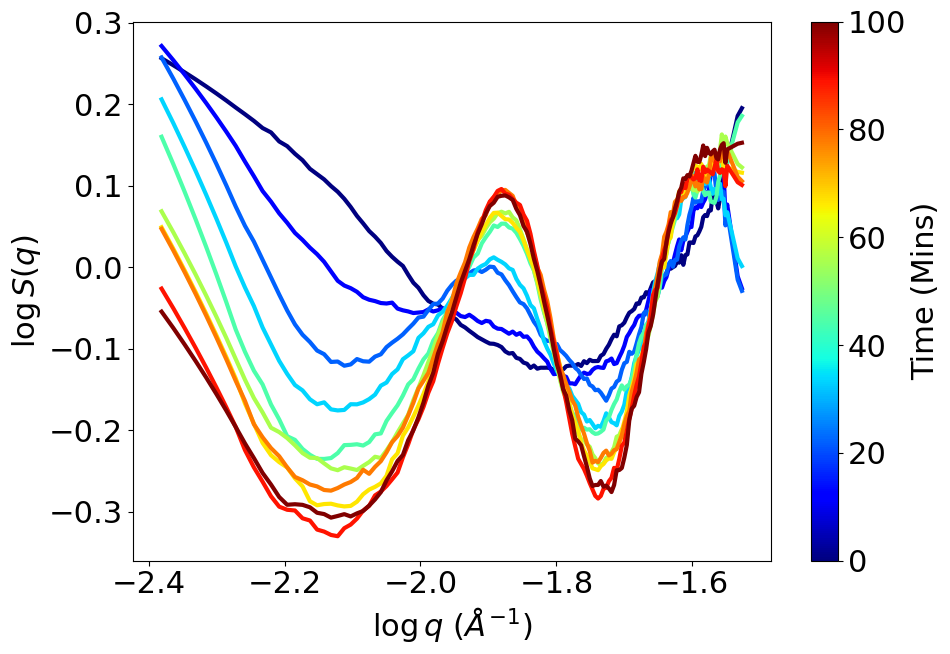

In [8]:
norm = colors.Normalize(vmin=0, vmax=100)
cmap = cm.jet
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
times = np.linspace(0,100, len(exp_saxs_data))
plt.rcParams.update({'font.size': 22})
fig, ax = plt.subplots(figsize=(10,7))
for i in range(len(exp_saxs_data)):
    data = exp_saxs_data[i]
    q, Iq, metrics = process_saxs_data(
        data[:,0], 
        data[:,1], 
        sg_window=15, 
        sg_poly=1, 
        return_metrics=True)
    ax.plot(q, Iq, linewidth = 3, color=sm.to_rgba(times[i]))
    ax.set_ylabel(r'$\log S(q)$')
    ax.set_xlabel(r'$ \log q \ (\AA^{-1})$')

cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
cbar.set_label('Time (Mins)')
plt.tight_layout()
#plt.savefig('../Figures/exp_saxs.png', dpi=600, bbox_inches="tight")

In [9]:
report_saxs_smoothing_metrics(metrics)

Metric,Value,Assessment,Interpretation
Typical linear intensity change,16.9%,Moderate,Typical percent change introduced by smoothing in linear intensity units.
Residual autocorr (lag 1),-0.151,Moderate,Closer to 0 means removed signal looks more like noise.
Shapiro p-value,3.14e-08,Bad,Higher is more consistent with normal residuals; secondary diagnostic only.
Peak shift,9.3300e-04,Moderate,Smaller means smoothing preserved SAXS feature positions.
Invariant relative change,1.96%,Good,Smaller means smoothing preserved integrated SAXS intensity.


## Load Simulated Data

In [10]:
file_path = '../Data/Simulations/Simulation_File_8/Optimization_Results/Sample_0/Density_0.005_U_0_46.95_r0_2.25_n_1.0_m_20.89/scattering_data_mcdfm_sq/'
filenames = sorted(os.listdir(file_path))

sim_saxs_data = []
for i in range(len(filenames)):
    saxs_data = np.load(file_path + filenames[i])
    sim_saxs_data.append(saxs_data)

Metric,Value,Assessment,Interpretation
Typical linear intensity change,4.3%,Good,Typical percent change introduced by smoothing in linear intensity units.
Residual autocorr (lag 1),0.763,Bad,Closer to 0 means removed signal looks more like noise.
Shapiro p-value,0.0217,Moderate,Higher is more consistent with normal residuals; secondary diagnostic only.
Peak shift,1.8532e-04,Good,Smaller means smoothing preserved SAXS feature positions.
Invariant relative change,0.84%,Good,Smaller means smoothing preserved integrated SAXS intensity.


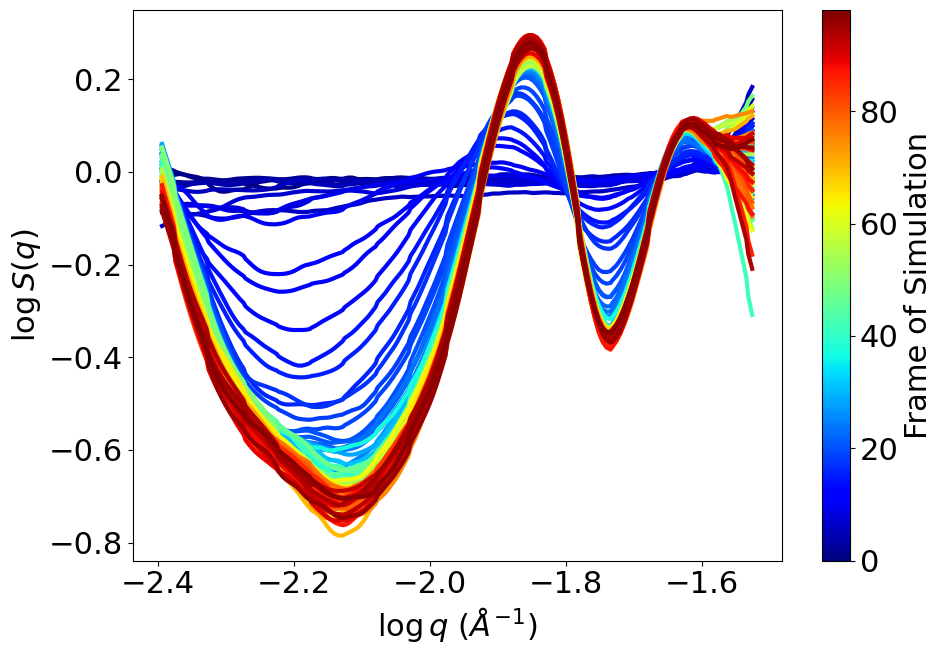

In [11]:
norm = colors.Normalize(vmin=0, vmax=len(sim_saxs_data))
cmap = cm.jet
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
times = np.linspace(0, len(sim_saxs_data)-1, len(sim_saxs_data))

fig, ax = plt.subplots(figsize=(10,7))
#for i in range(len(filenames)):
for i in range(len(sim_saxs_data)):
    data = sim_saxs_data[i]
    q, Iq, metrics = process_saxs_data(
        data[:,0], 
        data[:,1], 
        sg_window=11, 
        sg_poly=1, 
        return_metrics=True
    )
    ax.plot(q, Iq, linewidth = 3, color=sm.to_rgba(times[i]))
    ax.set_ylabel(r'$\log S(q)$')
    ax.set_xlabel(r'$ \log q \ (\AA^{-1})$')

cbar = fig.colorbar(sm, ax=ax, orientation='vertical')
cbar.set_label('Frame of Simulation')
plt.tight_layout()

report_saxs_smoothing_metrics(metrics)
#plt.savefig('../Figures/sim_saxs.png', dpi=600, bbox_inches="tight")

## Amplitude-Phase Distance

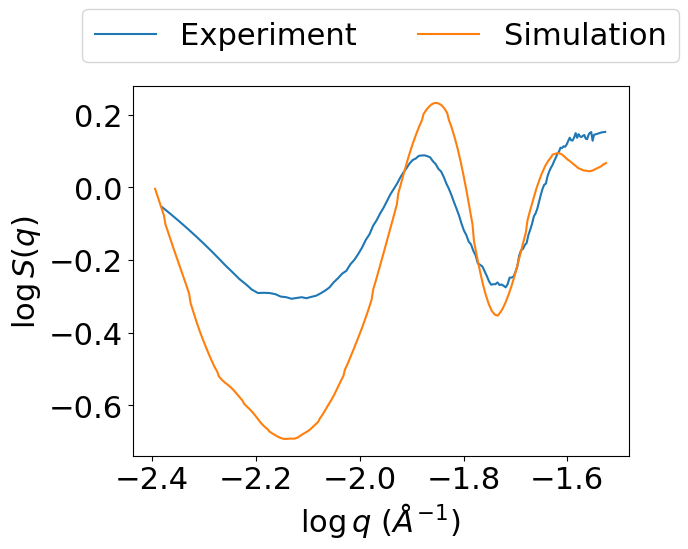

In [12]:
import numpy as np
import matplotlib.pyplot as plt 
from apdist.distances import AmplitudePhaseDistance as numpy_apdist 
from apdist.utils import plot_warping 
from apdist.geometry import SquareRootSlopeFramework as SRSF

sim_x = sim_saxs_data[41][:,0]
sim_y = sim_saxs_data[41][:,1]
sim_q, sim_Iq, _ = process_saxs_data(sim_x, sim_y, sg_window=11, sg_poly=1, return_metrics=True)

expt_x = exp_saxs_data[9][:,0]
expt_y = exp_saxs_data[9][:,1]
expt_q, expt_Iq, _ = process_saxs_data(expt_x, expt_y, sg_window=15, sg_poly=1, return_metrics=True)

fig, ax = plt.subplots()
ax.plot(expt_q, expt_Iq, label = 'Experiment')
ax.plot(sim_q, sim_Iq, label = 'Simulation')
ax.set_ylabel(r'$\log S(q)$')
ax.set_xlabel(r'$ \log q \ (\AA^{-1})$')
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.25))
plt.show()


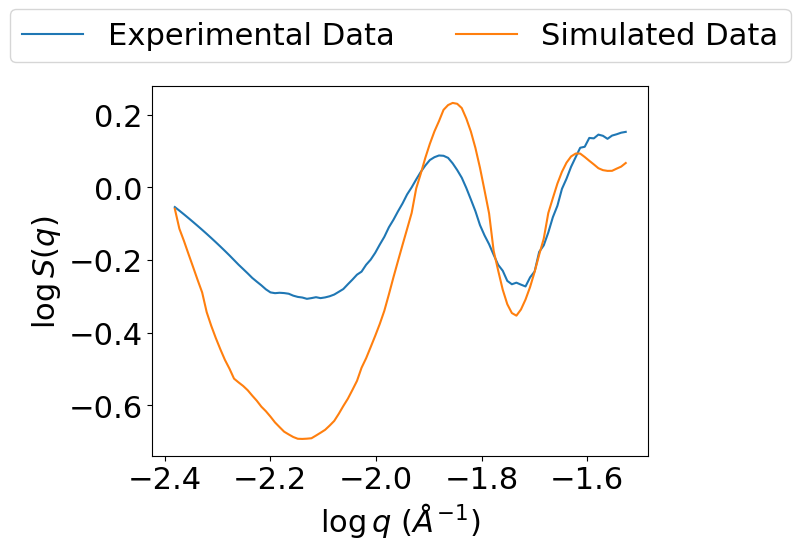

In [13]:
from scipy.interpolate import CubicSpline

spline_expt = CubicSpline(expt_q, expt_Iq)
x_dense = np.linspace(expt_q.min(), expt_q.max(), 100)
x_dense_scaled = (x_dense-min(x_dense))/(max(x_dense)-min(x_dense))

y_dense_expt = spline_expt(x_dense)

spline_sim = CubicSpline(sim_q, sim_Iq)
y_dense_sim = spline_sim(x_dense)

fig, ax = plt.subplots()
ax.plot(x_dense, y_dense_expt, label='Experimental Data')
ax.plot(x_dense, y_dense_sim, label='Simulated Data')
ax.set_ylabel(r'$\log S(q)$')
ax.set_xlabel(r'$ \log q \ (\AA^{-1})$')
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.25))
plt.show()

Amplitude : 0.5727, Phase : 0.2483, Total : 0.6242


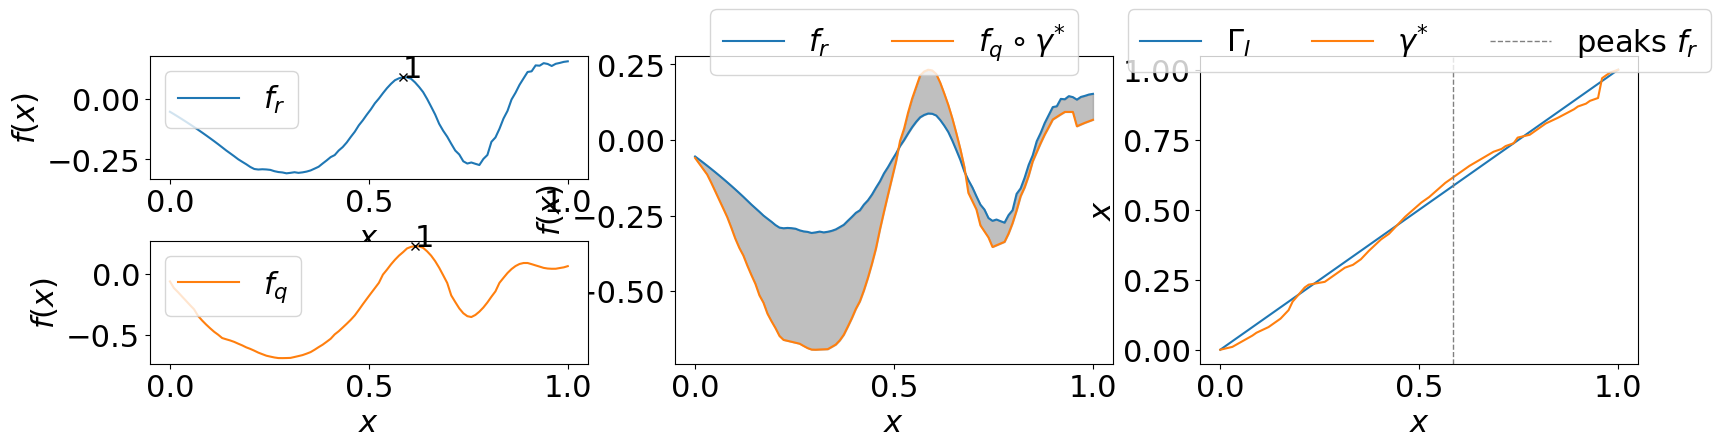

In [14]:
y_ref = y_dense_expt.copy()
y_query = y_dense_sim.copy()
a, p = numpy_apdist(x_dense_scaled, y_query, y_ref, **OPTIM_KWARGS_APDIST)
print("Amplitude : %2.4f, Phase : %2.4f, Total : %2.4f"%(a, p, np.abs(a+ 1j*p).item()))

srsf = SRSF(x_dense_scaled)
q_query = srsf.to_srsf(y_query)
q_ref = srsf.to_srsf(y_ref)
gamma = srsf.get_gamma(q_ref, q_query, **OPTIM_KWARGS_APDIST)
f_query_gamma = srsf.warp_f_gamma(y_query, gamma)
plot_warping(x_dense_scaled, y_ref, y_query, f_query_gamma, gamma)
plt.show()

In [15]:
def get_curves(expt_id, sim_id):
    sim_x = sim_saxs_data[sim_id][:,0]
    sim_y = sim_saxs_data[sim_id][:,1]
    sim_q, sim_Iq = process_saxs_data(sim_x, sim_y, sg_window=11, sg_poly=1, return_metrics=False)

    expt_x = exp_saxs_data[expt_id][:,0]
    expt_y = exp_saxs_data[expt_id][:,1]
    expt_q, expt_Iq = process_saxs_data(expt_x, expt_y, sg_window=15, sg_poly=1, return_metrics=False)

    spline_expt = CubicSpline(expt_q, expt_Iq)
    x_dense = np.linspace(expt_q.min(), expt_q.max(), 100)
    x_dense_scaled = (x_dense-min(x_dense))/(max(x_dense)-min(x_dense))

    y_dense_expt = spline_expt(x_dense)

    spline_sim = CubicSpline(sim_q, sim_Iq)
    y_dense_sim = spline_sim(x_dense)

    return x_dense, x_dense_scaled, y_dense_expt, y_dense_sim

def compare_pair(expt_id, sim_id):
    x_dense, x_dense_scaled, y_dense_expt, y_dense_sim = get_curves(expt_id, sim_id)
    fig, ax = plt.subplots()
    ax.plot(x_dense, y_dense_expt, label='Experimental Data')
    ax.plot(x_dense, y_dense_sim, label='Simulated Data')
    ax.set_ylabel(r'$\log S(q)$')
    ax.set_xlabel(r'$ \log q \ (\AA^{-1})$')
    ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.25))
    plt.show()

    optim_kwargs = {"optim":"DP", "grid_dim":20, "lambda":1e-1}
    y_ref = y_dense_expt.copy()/np.max(y_dense_expt)
    y_query = y_dense_sim.copy()/np.max(y_dense_sim)
    print(f"Reference curve min: {y_ref.min():.4f}, max: {y_ref.max():.4f}")
    print(f"Query curve min: {y_query.min():.4f}, max: {y_query.max():.4f}")
    a, p = numpy_apdist(x_dense_scaled, y_ref, y_query, **OPTIM_KWARGS_APDIST)
    print(f"(expt_id={expt_id}, sim_id={sim_id}) "
        f"Amplitude : {a:.4f}, Phase : {p:.4f}, Total : {np.abs(a + 1j*p).item():.4f}")

    srsf = SRSF(x_dense_scaled)
    q_query = srsf.to_srsf(y_query)
    q_ref = srsf.to_srsf(y_ref)
    gamma = srsf.get_gamma(q_ref, q_query, **OPTIM_KWARGS_APDIST)
    f_query_gamma = srsf.warp_f_gamma(y_query, gamma)
    plot_warping(x_dense_scaled, y_ref, y_query, f_query_gamma, gamma)
    plt.show()

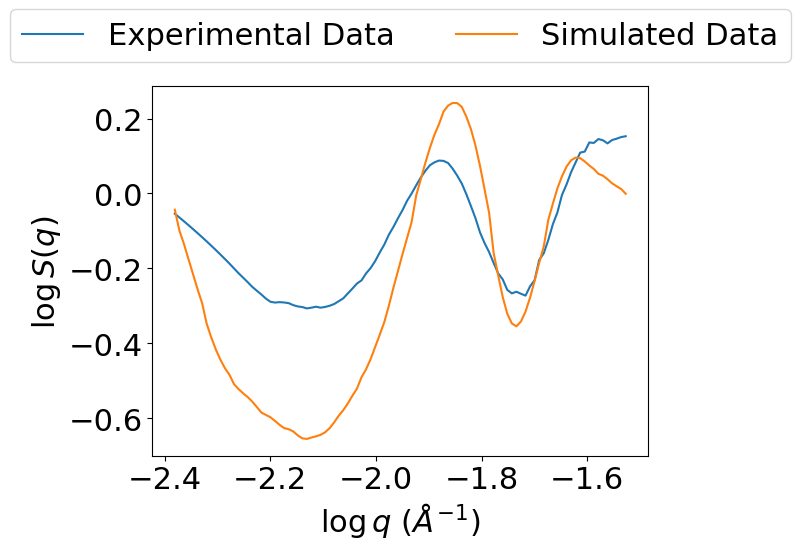

Reference curve min: -2.0101, max: 1.0000
Query curve min: -2.7126, max: 1.0000
(expt_id=9, sim_id=38) Amplitude : 1.1219, Phase : 0.2971, Total : 1.1606


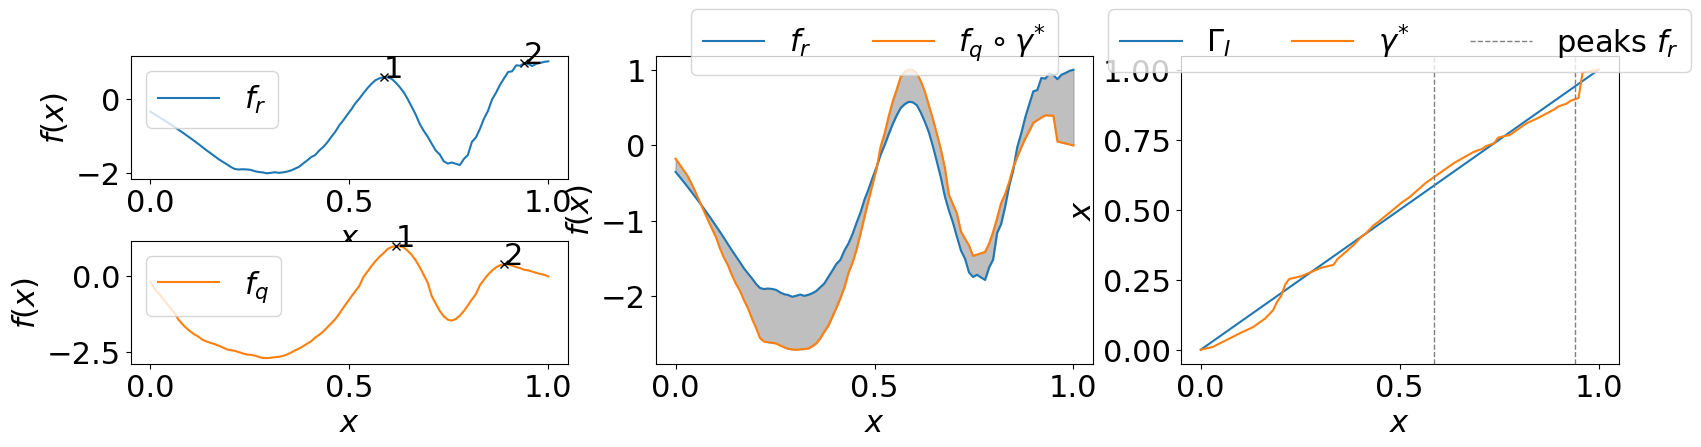

In [16]:
compare_pair(9, 38)

In [17]:
def plot_aligned_sim_to_expt(expt_id):
    x_dense, x_dense_scaled, y_dense_expt, y_dense_sim = get_curves(expt_id, 38)
    cmap = plt.get_cmap("coolwarm")
    fig, ax = plt.subplots()
    distances = np.zeros(len(sim_saxs_data))
    for sim_id in range(len(sim_saxs_data)):
        x_dense,x_dense_scaled, y_dense_expt, y_dense_sim = get_curves(expt_id, sim_id)
        y_ref = y_dense_expt.copy()
        y_query = y_dense_sim.copy()

        amplitude, phase = numpy_apdist(x_dense_scaled, y_ref, y_query, **OPTIM_KWARGS_APDIST)
        dist = np.abs(amplitude + 1j*phase).item()
        distances[sim_id] = dist
        print(f"Expt ID: {expt_id}, Sim ID: {sim_id}, Distance: {dist:.4f}", end="\r")
    
    norm = colors.Normalize(vmin=min(distances), vmax=max(distances))

    for sim_id, phase in enumerate(distances):
        _,_,_, y_dense_sim = get_curves(expt_id, sim_id)
        ax.plot(x_dense, y_dense_sim, color=cmap(norm(phase)), alpha=0.5)
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Distance')
    ax.plot(x_dense, y_ref, color="k", lw=2.0, label=f"Experiment ID: {expt_id}")
    ax.set_ylabel(r'$\log S(q)$')
    ax.set_xlabel(r'$ \log q \ (\AA^{-1})$')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.25))
    plt.show()

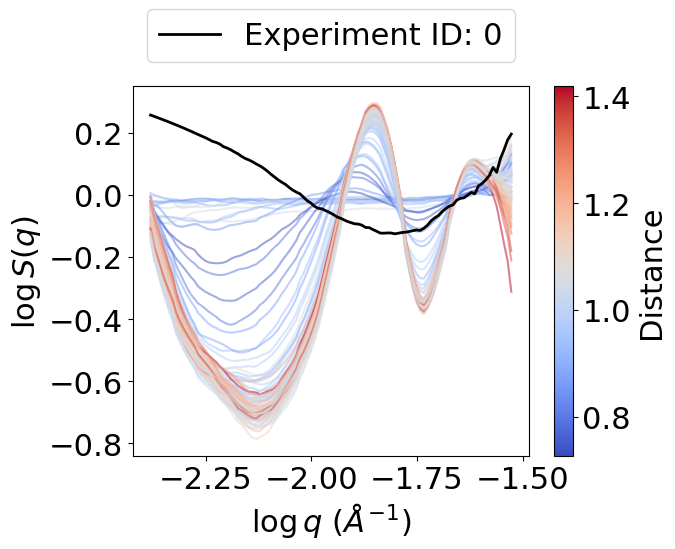

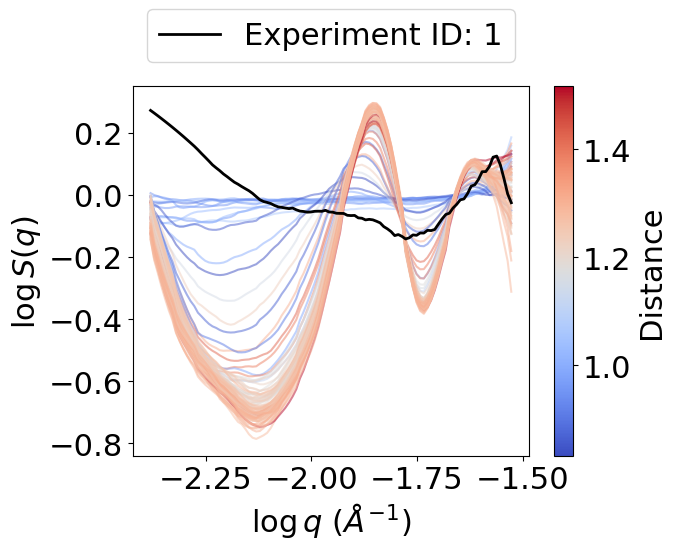

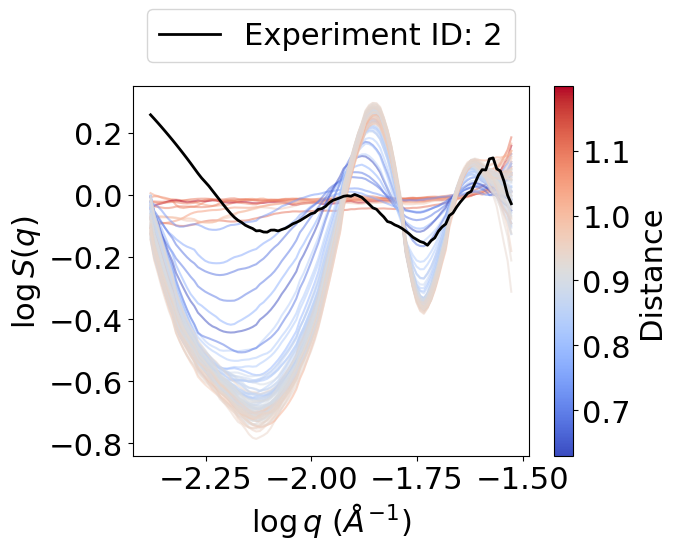

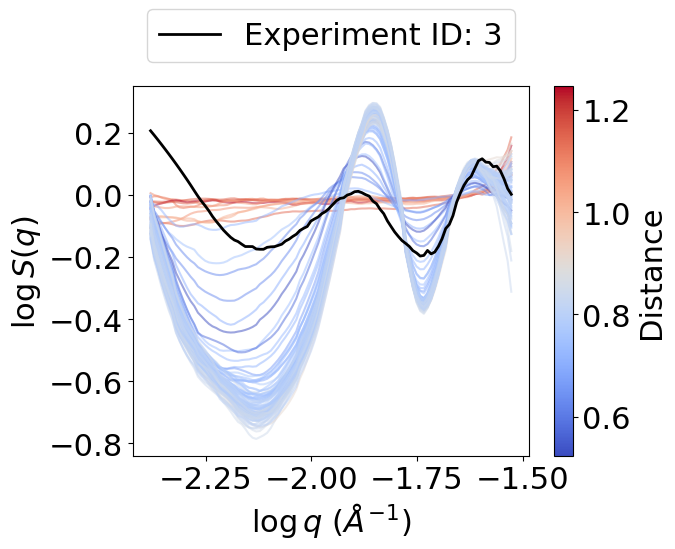

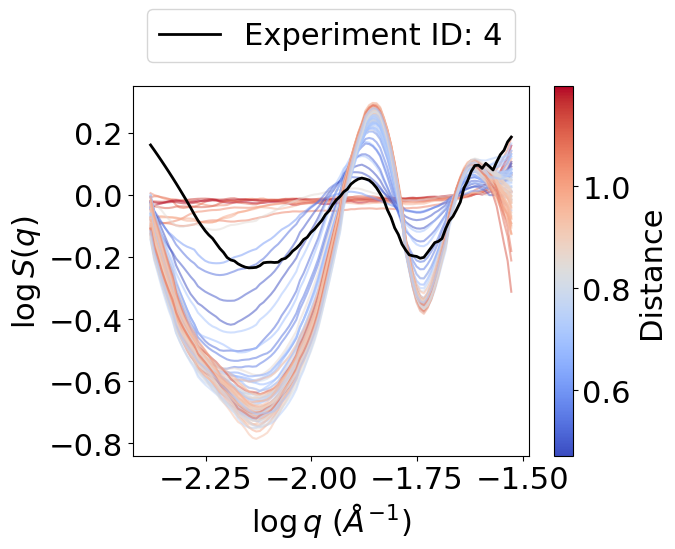

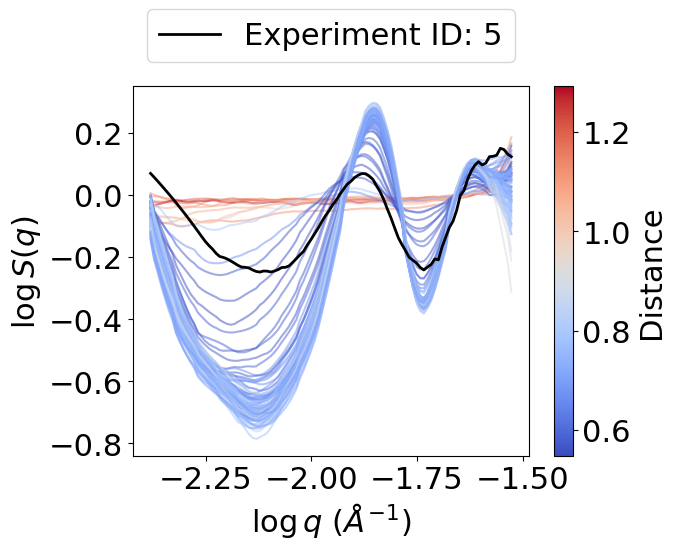

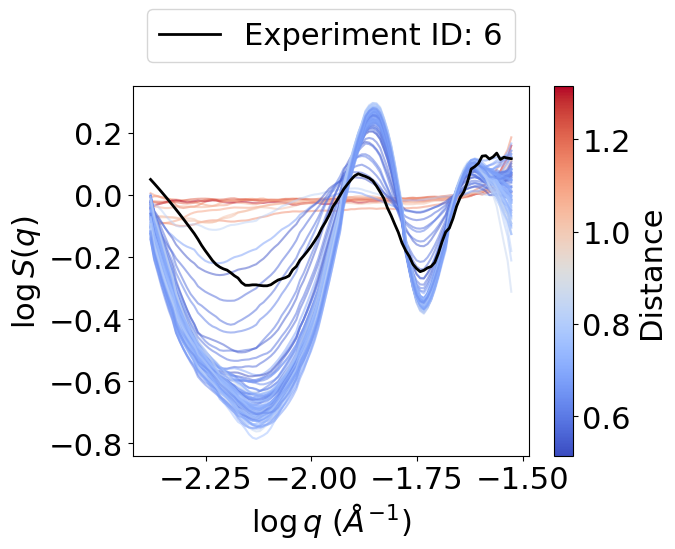

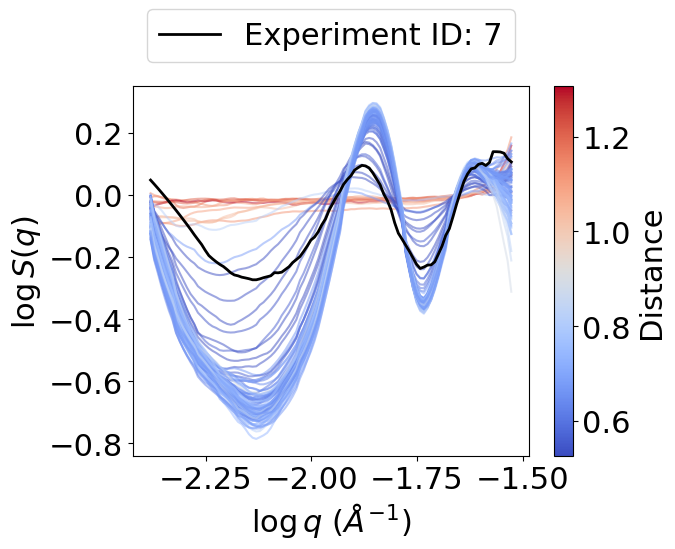

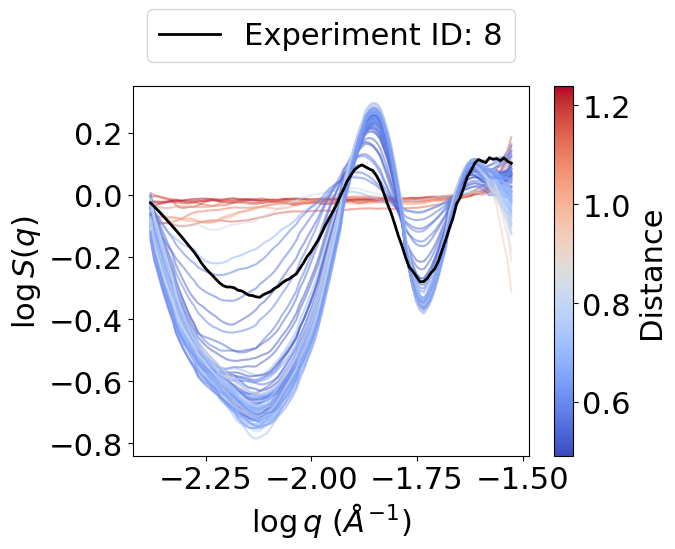

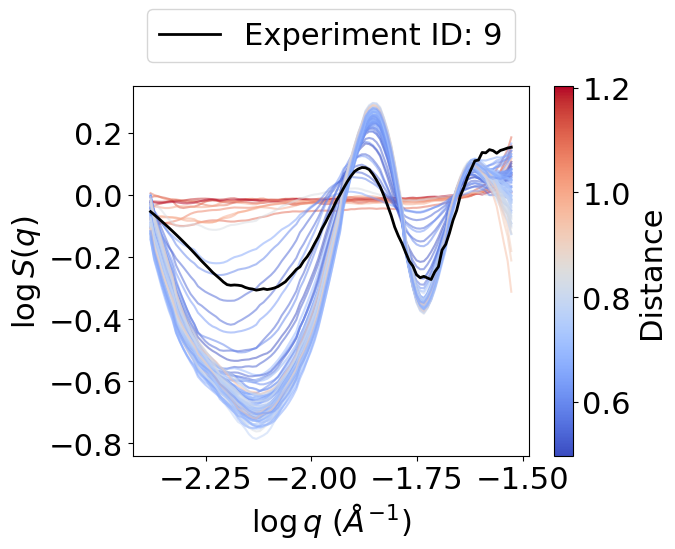

In [18]:
for expt_id in range(len(exp_saxs_data)):
    plot_aligned_sim_to_expt(expt_id)

In [19]:
def shape_distance_saxs_numpy(expt_id, sim_id):
    _, x_dense_scaled, y_dense_expt, y_dense_sim = get_curves(expt_id, sim_id)

    y_ref = y_dense_expt.copy()
    y_query = y_dense_sim.copy()
    amplitude, phase = numpy_apdist(x_dense_scaled, y_ref, y_query, **OPTIM_KWARGS_APDIST)
    return np.abs(amplitude + 1j*phase).item()   

shape_distance_saxs_numpy(0, 0)


1.0231093521343666

In [20]:
import time 

def create_distance_matrix(exp_data, sim_data):
    score_matrix = np.zeros((len(exp_data), len(sim_data)))

    for expt_id in range(len(exp_data)):
        for sim_id in range(len(sim_data)):
            start = time.time()
            dist = shape_distance_saxs_numpy(expt_id, sim_id)
            
            score_matrix[expt_id, sim_id] = dist
            end = time.time()
            print(f"Distance between exp {expt_id} and sim {sim_id}: {dist:.4f} (Time: {end - start:.4f}s)")

    return score_matrix

score_matrix_apdist = create_distance_matrix(exp_saxs_data, sim_saxs_data)

Distance between exp 0 and sim 0: 1.0231 (Time: 0.1146s)
Distance between exp 0 and sim 1: 0.9134 (Time: 0.1133s)
Distance between exp 0 and sim 2: 0.8178 (Time: 0.1132s)
Distance between exp 0 and sim 3: 0.8966 (Time: 0.1128s)
Distance between exp 0 and sim 4: 0.9345 (Time: 0.1121s)
Distance between exp 0 and sim 5: 1.0750 (Time: 0.1117s)
Distance between exp 0 and sim 6: 1.0494 (Time: 0.1122s)
Distance between exp 0 and sim 7: 1.0495 (Time: 0.1154s)
Distance between exp 0 and sim 8: 0.9293 (Time: 0.1151s)
Distance between exp 0 and sim 9: 0.9817 (Time: 0.1155s)
Distance between exp 0 and sim 10: 0.8593 (Time: 0.1152s)
Distance between exp 0 and sim 11: 0.7270 (Time: 0.1143s)
Distance between exp 0 and sim 12: 0.7929 (Time: 0.1146s)
Distance between exp 0 and sim 13: 0.7569 (Time: 0.1135s)
Distance between exp 0 and sim 14: 0.7998 (Time: 0.1123s)
Distance between exp 0 and sim 15: 0.8740 (Time: 0.1135s)
Distance between exp 0 and sim 16: 0.9419 (Time: 0.1152s)
Distance between exp 0 a

## Compute and Plot distance matrices

In [21]:
score_matrix_MSE = series_alignment.create_distance_matrix(exp_saxs_data, sim_saxs_data,'log_mse', q_range=(0.004, 0.02))

Comparing curves with metric: log_mse for 94 points in range [4.160e-03, 1.995e-02]
Experimental intensities: min=6.644e-01, max=1.842e+00
Simulated intensities: min=8.609e-01, max=1.026e+00
Shape of experimental intensities: (94, 1), Shape of simulated intensities: (94, 1)
Comparing curves with metric: log_mse for 94 points in range [4.160e-03, 1.995e-02]
Experimental intensities: min=6.644e-01, max=1.842e+00
Simulated intensities: min=8.904e-01, max=1.018e+00
Shape of experimental intensities: (94, 1), Shape of simulated intensities: (94, 1)
Comparing curves with metric: log_mse for 94 points in range [4.160e-03, 1.995e-02]
Experimental intensities: min=6.644e-01, max=1.842e+00
Simulated intensities: min=9.373e-01, max=9.951e-01
Shape of experimental intensities: (94, 1), Shape of simulated intensities: (94, 1)
Comparing curves with metric: log_mse for 94 points in range [4.160e-03, 1.995e-02]
Experimental intensities: min=6.644e-01, max=1.842e+00
Simulated intensities: min=8.847e-01

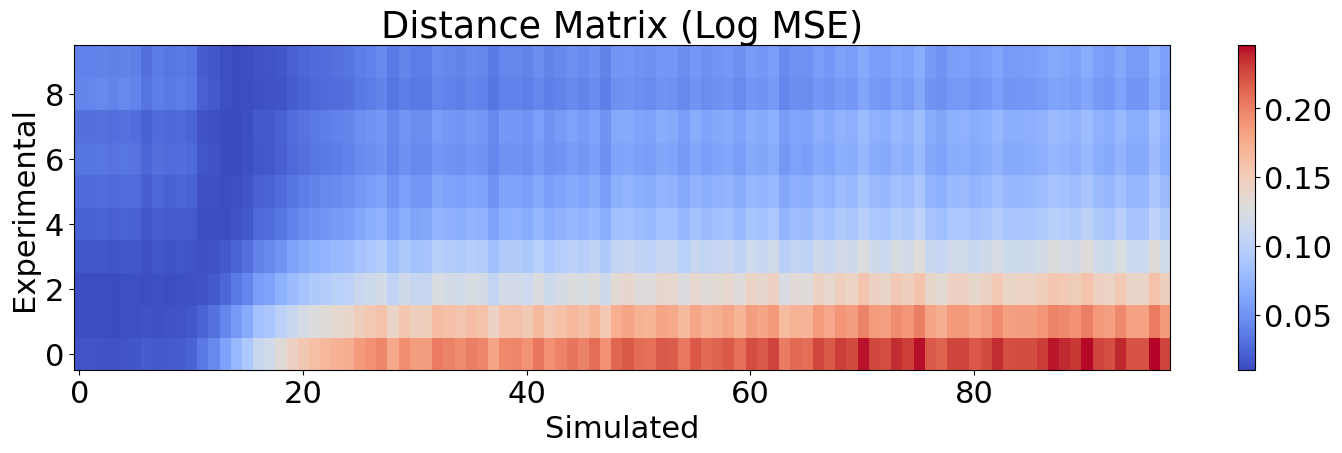

In [22]:
fig, ax = plt.subplots(figsize=(15,5))
img = ax.imshow(score_matrix_MSE, cmap='coolwarm', aspect='auto', origin='lower')
ax.set_xlabel('Simulated')
ax.set_ylabel('Experimental')
ax.set_title('Distance Matrix (Log MSE)')
plt.colorbar(img, ax=ax)
plt.tight_layout()

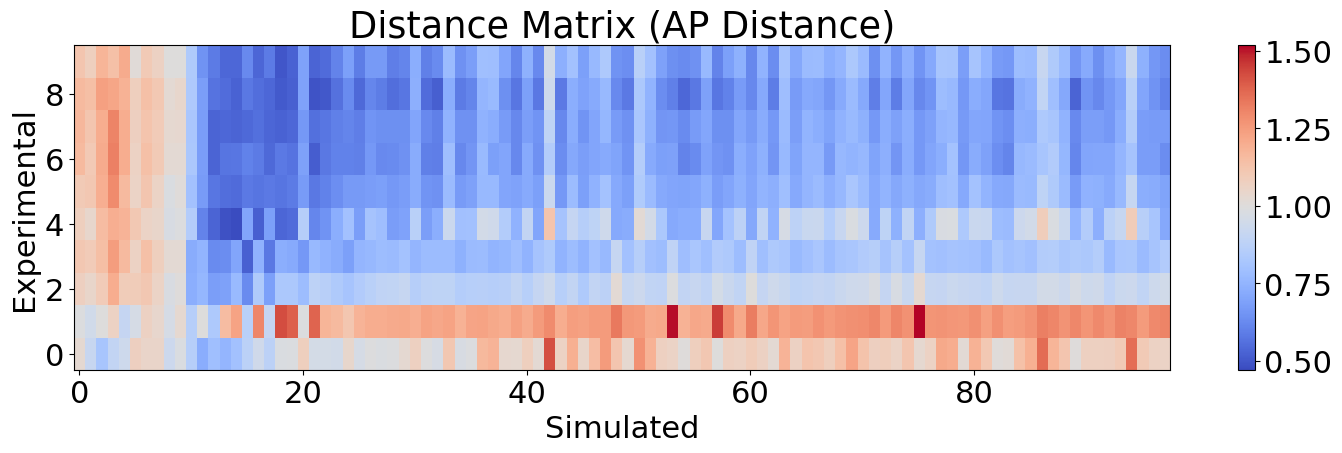

In [23]:
fig, ax = plt.subplots(figsize=(15,5))
img = ax.imshow(score_matrix_apdist, cmap='coolwarm', aspect='auto', origin='lower')
ax.set_xlabel('Simulated')
ax.set_ylabel('Experimental')
ax.set_title('Distance Matrix (AP Distance)')
plt.colorbar(img, ax=ax)
plt.tight_layout()

## Align the Curves Based on Distance

In [24]:
idx_cols_MSE, total_dist_MSE = series_alignment.align_monotone_min(score_matrix_MSE)

In [25]:
idx_cols_apdist, total_dist_apdist = series_alignment.align_monotone_min(score_matrix_apdist)

## Compare Curves by Plotting

In [26]:
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

def plot_compared_curves_grid(exp_data, idx_sim):
    norm = colors.Normalize(vmin=0, vmax=100)
    cmap = cm.jet
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    times = np.linspace(0, 100, len(exp_data))

    fig, ax = plt.subplots(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])
    plt.ylabel(r'$\log S(q)$', labelpad=5, fontsize=20)
    plt.xlabel(r'$\log q$ ($\AA^{-1}$)', labelpad=5, fontsize=20)

    gs = fig.add_gridspec(5, 2, hspace=0, wspace=0)
    axs = gs.subplots(sharex='col', sharey='row')
    axs = axs.flatten()

    for expt_id in range(len(exp_data)):
        ax = axs[expt_id]
        ax.tick_params(axis="x", which="both", labelbottom=False)

        matched_sim_id = idx_sim[expt_id].item() if isinstance(idx_sim[expt_id], np.int64) else idx_sim[expt_id]
        x_dense, x_dense_scaled, y_dense_expt, y_dense_sim = get_curves(expt_id, matched_sim_id)

        ax.scatter(x_dense, y_dense_expt, linewidth=0.5, color=sm.to_rgba(times[expt_id]))
        ax.plot(x_dense, y_dense_sim, linewidth=3, color='k')
        ax.set_title(f"({expt_id}, {matched_sim_id})", fontsize=15, y=0.8)
        ax.set_yticks([])
        ax.set_xticks([])
        ax.set_xticklabels([])

    simulated_handle = Line2D([0], [0], color='k', lw=3)

    experimental_handle = (
        Line2D([0], [0], marker='o', linestyle='None', markersize=8,
               markerfacecolor=cmap(0.1), markeredgecolor='none'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=8,
               markerfacecolor=cmap(0.5), markeredgecolor='none'),
        Line2D([0], [0], marker='o', linestyle='None', markersize=8,
               markerfacecolor=cmap(0.9), markeredgecolor='none'),
    )

    fig.legend(
        [simulated_handle, experimental_handle],
        ['Simulated data', 'Experimental data'],
        handler_map={tuple: HandlerTuple(ndivide=None)},
        loc='upper center',
        bbox_to_anchor=(0.5, 0.98),
        ncol=2,
        frameon=False,
        fontsize=16
    )

    cbar_ax = fig.add_axes([0.92, 0.15, 0.03, 0.7])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Experimental Data Time (Mins)')

    plt.tight_layout(rect=[0, 0, 0.9, 0.94])
    plt.show()

/var/folders/rp/7vyn7s1x0nnbgmjhr2bvs_1c002hph/T/ipykernel_41198/2570855369.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.94])


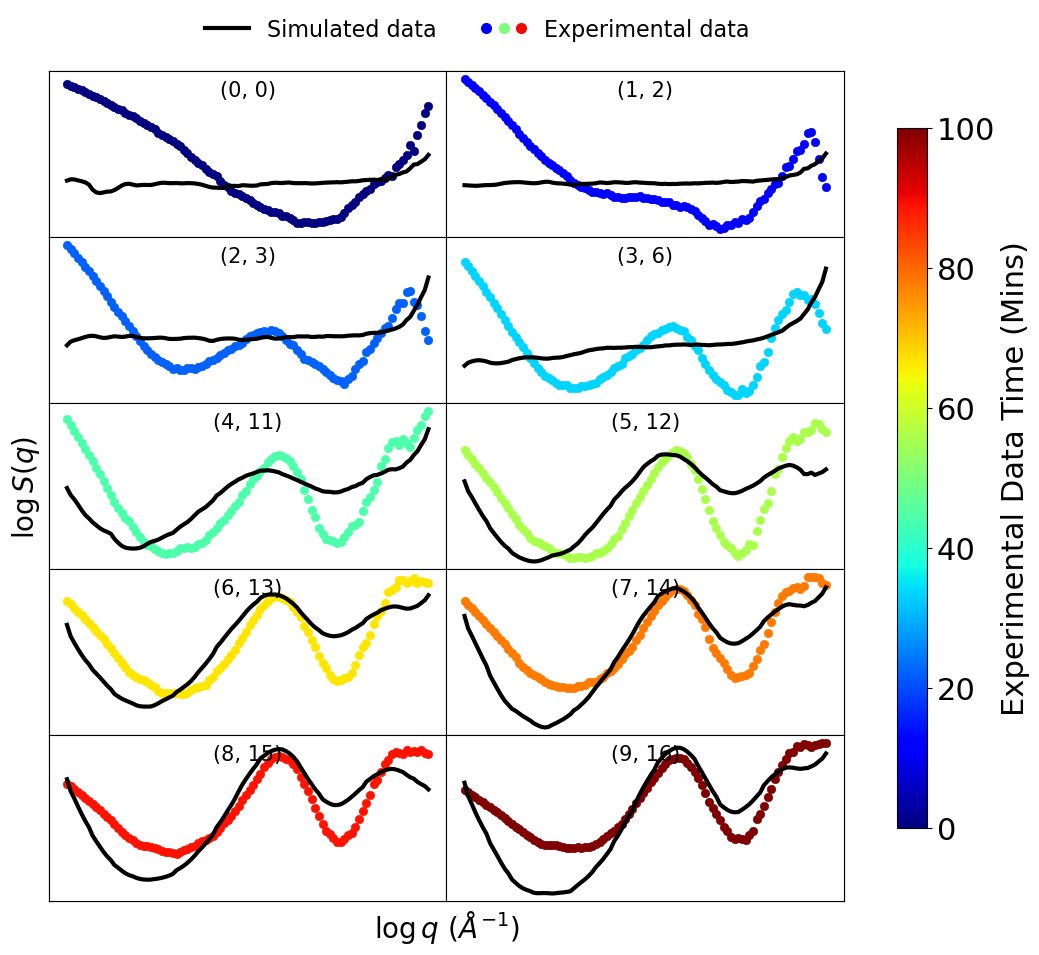

In [27]:
plot_compared_curves_grid(exp_saxs_data, idx_cols_MSE)

/var/folders/rp/7vyn7s1x0nnbgmjhr2bvs_1c002hph/T/ipykernel_41198/2570855369.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.94])


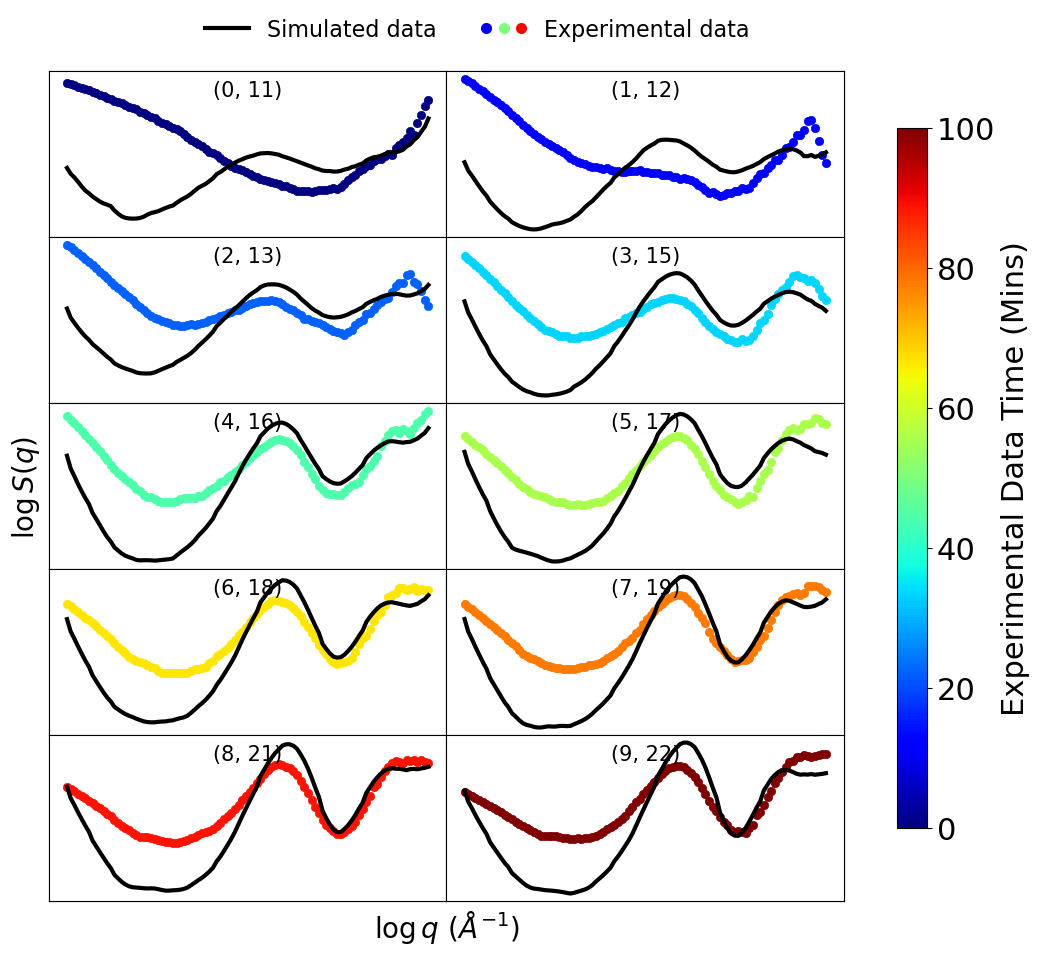

In [28]:
plot_compared_curves_grid(exp_saxs_data, idx_cols_apdist)

In [29]:
def plot_alignment_with_cost(cost_matrix, idx_cols_min, save_path=None):
    """
    Plot cost matrix heatmap with alignment path overlaid.
    """

    idx_cols_min = np.array(idx_cols_min)
    n_exp, n_sim = cost_matrix.shape
    exp_indices = np.arange(n_exp)

    plt.figure(figsize=(15, 3))
    plt.imshow(cost_matrix, aspect='auto', origin='lower', cmap="coolwarm")
    plt.colorbar(label="Distance", aspect=7)
    plt.plot(idx_cols_min, exp_indices, marker='o', color='k', label='Series Alignment (Distance: 1150)')

    plt.xlabel("Simulated Index")
    plt.ylabel("Exp. Index")
    plt.tight_layout()
    plt.show()

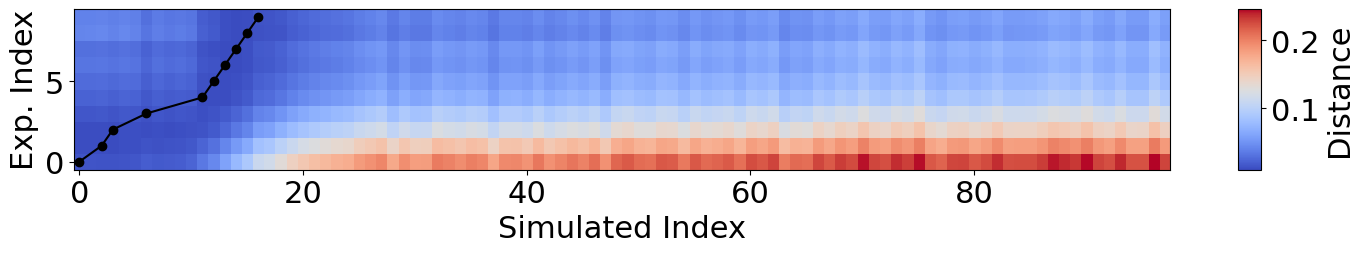

In [30]:
plot_alignment_with_cost(score_matrix_MSE, idx_cols_MSE)

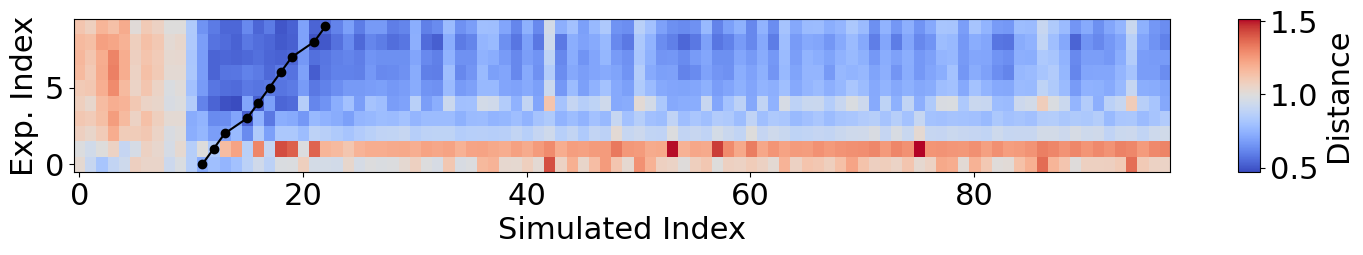

In [31]:
plot_alignment_with_cost(score_matrix_apdist, idx_cols_apdist)